# **50:50 Beam Splitter**

This notebook demonstrates how to calculate the reflectance of a multilayer thin-film stack designed as a 50:50 beam splitter deposited on a glass substrate. The reflectance is computed for both s-polarization and p-polarization across a wavelength range of 525 nm to 575 nm, and for incident angles from 0° to 10°.


## **Introduction**

We will use the Transfer Matrix Method (TMM) to analyze the reflectance and transmittance of a multilayer thin-film structure designed to function as a 50:50 beam splitter in the visible spectrum. The multilayer consists of alternating layers of Titanium Dioxide (TiO₂) and Silicon Dioxide (SiO₂) deposited on a glass substrate, with air as the incident medium.

![title](../_static/stack_of_beam_splitter.png)

In this example, the calculation is done for two polarizations:
- **s-polarization**: Electric field perpendicular to the plane of incidence.
- **p-polarization**: Electric field parallel to the plane of incidence.

We will calculate the reflectance as a function of wavelength and angle of incidence for each polarization.

---

## **Materials and Layer Thickness**

We are considering the following material stack:

- **Air** as the incident medium.
- **TiO₂ (Titanium Dioxide)** with a thickness of 58.5 nm.
- **SiO₂ (Silicon Dioxide)** with a thickness of 94.8 nm.
- **SiO₂ (Silicon Dioxide)** as the glass substrate.


---

## **Python Implementation**

In this section, we implement the TMM algorithm using the `tmmax` library, which is designed for high-performance multilayer simulations with vectorized operations using the `jax` library.

In [ ]:
import jax.numpy as jnp
from tmmax.tmm import tmm

# Define the materials and their thicknesses
material_list =  ["Air", "TiO2", "SiO2","TiO2","SiO2","TiO2","SiO2","TiO2", "SiO2"]
thickness_list = jnp.array([58.5e-9, 94.8e-9,58.5e-9, 94.8e-9,58.5e-9, 94.8e-9,58.5e-9])

# Define the wavelength range (525 nm to 575 nm) and angles of incidence (0° to 10°)
wavelength_arr = jnp.linspace(525e-9, 575e-9, 1000)
angle_of_incidences = jnp.linspace(0, (10*jnp.pi/180), 1000)

# Calculate reflectance for s-polarization
result_s = tmm(material_list=material_list, thickness_list=thickness_list,
             wavelength_arr=wavelength_arr, angle_of_incidences=angle_of_incidences,
             polarization="s")

# Calculate reflectance for p-polarization
result_p = tmm(material_list=material_list, thickness_list=thickness_list,
             wavelength_arr=wavelength_arr, angle_of_incidences=angle_of_incidences,
             polarization="p")

## **Visualization of Results**

We will now visualize the reflectance for both s-polarization and p-polarization as a function of wavelength and angle of incidence. The color map will represent the reflectance percentage.

### **Reflectance Results**

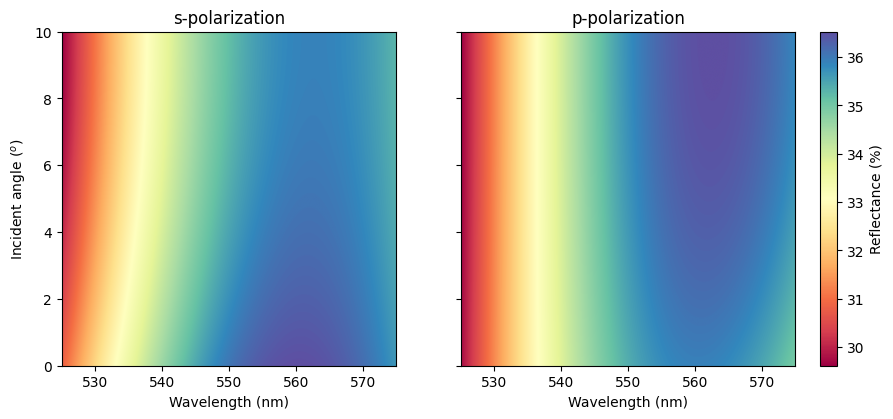

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow(result_s[0]*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow(result_p[0]*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Reflectance (%)')

plt.savefig("beam_splitter_reflectance_s_p.png", dpi=600)
plt.show()

### **Transmittance Results**

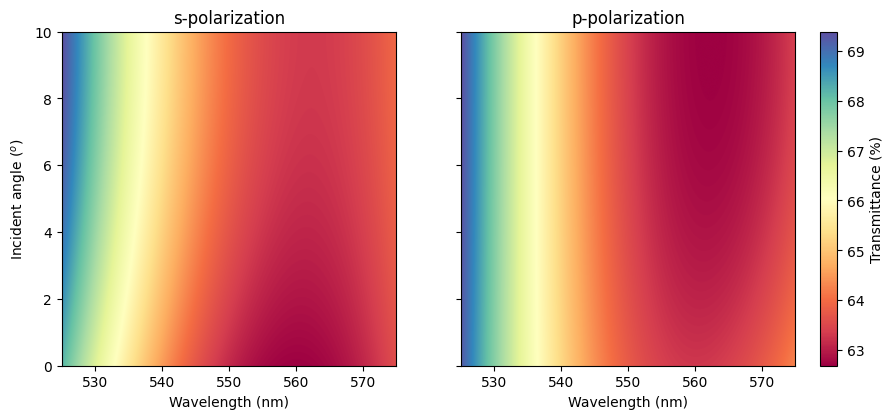

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow(result_s[1]*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow(result_p[1]*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Transmittance (%)')

plt.savefig("beam_splitter_transmittance_s_p.png", dpi=600)
plt.show()

### **Absorbance Results**

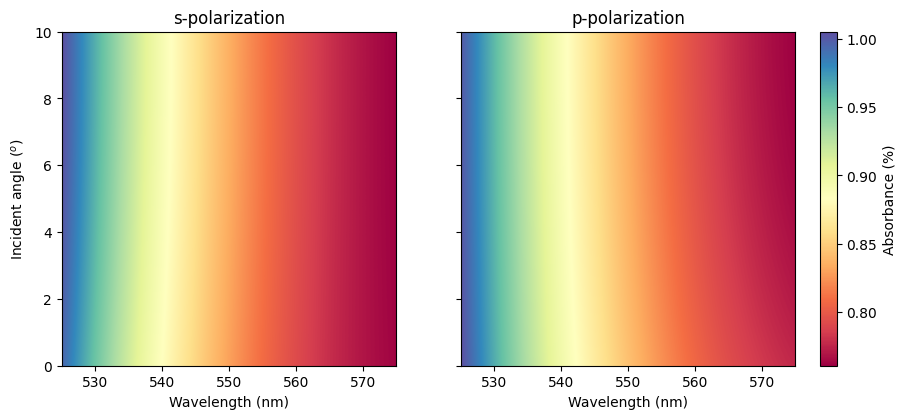

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow((1 - result_s[0] - result_s[1])*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow((1 -result_p[0] - result_p[1])*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Absorbance (%)')

plt.savefig("beam_splitter_absorbance_s_p.png", dpi=600)
plt.show()